<a href="https://colab.research.google.com/github/daaim10/auto_encoders/blob/main/auto_encoder_with_convolution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install torch torchvision matplotlib

In [2]:
from torchvision import transforms

transform = transforms.ToTensor()
from torchvision.datasets import FashionMNIST
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torchvision.datasets import FashionMNIST
from torchvision import transforms
from torch.utils.data import DataLoader
train_dataset = FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

100%|██████████| 26.4M/26.4M [00:00<00:00, 117MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.77MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 60.9MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.5MB/s]


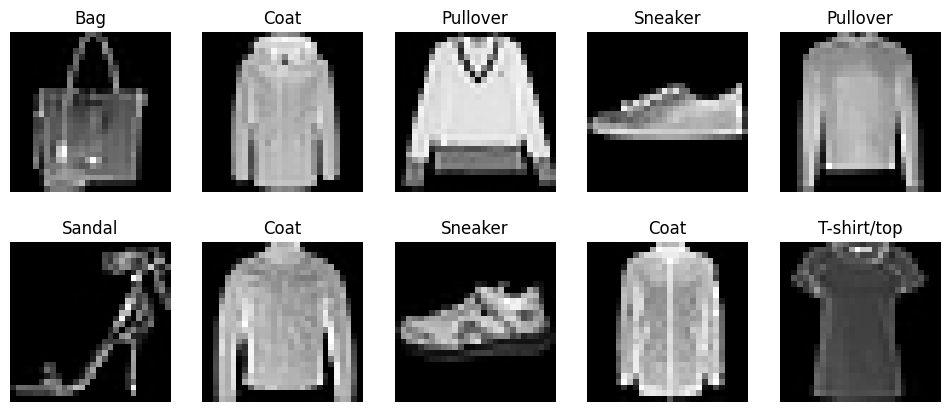

In [3]:
classes = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]
images, labels = next(iter(train_loader))

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(classes[labels[i]])
    plt.axis('off')

plt.show()

In [4]:
import torch
import torch.nn as nn

class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(

            # Input: (1,28,28)

            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            # Output: (16,14,14)

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.ReLU()

            # Output: (32,7,7)
        )

        # Decoder
        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(
                32,
                16,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.ReLU(),

            # Output: (16,14,14)

            nn.ConvTranspose2d(
                16,
                1,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),

            nn.Sigmoid()

            # Output: (1,28,28)
        )

    def forward(self, x):

        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        return decoded

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ConvAutoencoder().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [6]:
num_epochs = 10

for epoch in range(num_epochs):

    running_loss = 0

    for images, _ in train_loader:

        images = images.to(device)

        outputs = model(images)

        loss = criterion(outputs, images)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss = {avg_loss:.6f}")

Epoch [1/10] Loss = 0.014656
Epoch [2/10] Loss = 0.002524
Epoch [3/10] Loss = 0.001672
Epoch [4/10] Loss = 0.001271
Epoch [5/10] Loss = 0.001042
Epoch [6/10] Loss = 0.000876
Epoch [7/10] Loss = 0.000757
Epoch [8/10] Loss = 0.000674
Epoch [9/10] Loss = 0.000625
Epoch [10/10] Loss = 0.000583


In [7]:
images, _ = next(iter(test_loader))

sample = images[:8].to(device)

with torch.no_grad():

    reconstructed = model(sample)

sample = sample.cpu()

reconstructed = reconstructed.cpu()

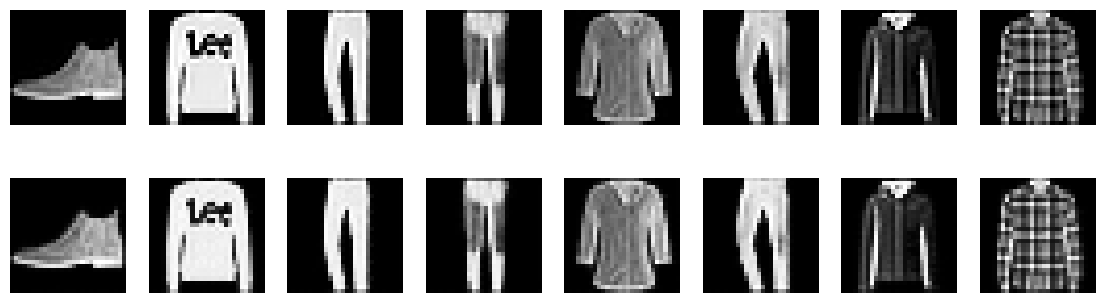

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 8, figsize=(14,4))

for i in range(8):

    axes[0,i].imshow(sample[i].squeeze(), cmap='gray')
    axes[0,i].axis("off")

    axes[1,i].imshow(reconstructed[i].squeeze(), cmap='gray')
    axes[1,i].axis("off")

plt.show()